# Hohenegger & Stevens (2016) – Replicación de Figuras
### *Coupled radiative convective equilibrium simulations with explicit and parameterized convection*
**Journal of Advances in Modeling Earth Systems** | DOI: 10.1002/2016MS000666

---
Este notebook genera datos sintéticos representativos de las simulaciones del artículo
y replica la estructura visual de cada figura. Los datos son construidos a partir de los
valores numéricos, tendencias y descripciones cualitativas reportadas en el texto.

| Figura | Contenido |
|--------|-----------|
| Fig. 1 | Frecuencia de ocurrencia convectiva – U500 |
| Fig. 2 | Liquid Water Path en U500, U50, U5 (día 16.5) |
| Fig. 3 | Rango intercuartil de agua columnar – distintas d |
| Fig. 4 | Presupuesto de humedad – simulaciones que agregan |
| Fig. 5 | Presupuesto de humedad – SST homogeneizada |
| Fig. 6 | LWP en U50D – ciclo diurno |
| Fig. 7 | Presupuesto de energía superficial: U50D vs U50D_noagg |
| Fig. 8 | Mapa de precipitación E50D + histograma columna de agua |
| Fig. 9 | Marco de Gregory: energía neta vs ΔSST |
| Tab. 1 | Valores de equilibrio U50D / E50D |
| Tab. 2 | Parámetros de retroalimentación U50D_pert / E50D_pert |

## Celda 0 – Importaciones y configuración global

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
from scipy.ndimage import gaussian_filter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'lines.linewidth': 1.8,
})

np.random.seed(42)
print('Configuracion cargada correctamente.')

Configuracion cargada correctamente.


## Figure 1 – Distribución espacial de frecuencia de ocurrencia convectiva (U500)

Replica la grilla de paneles diarios que muestra la evolución desde convección
aleatoria (días 1-5) hacia un estado auto-agregado (~día 34).
El último panel incluye el viento horizontal superficial.

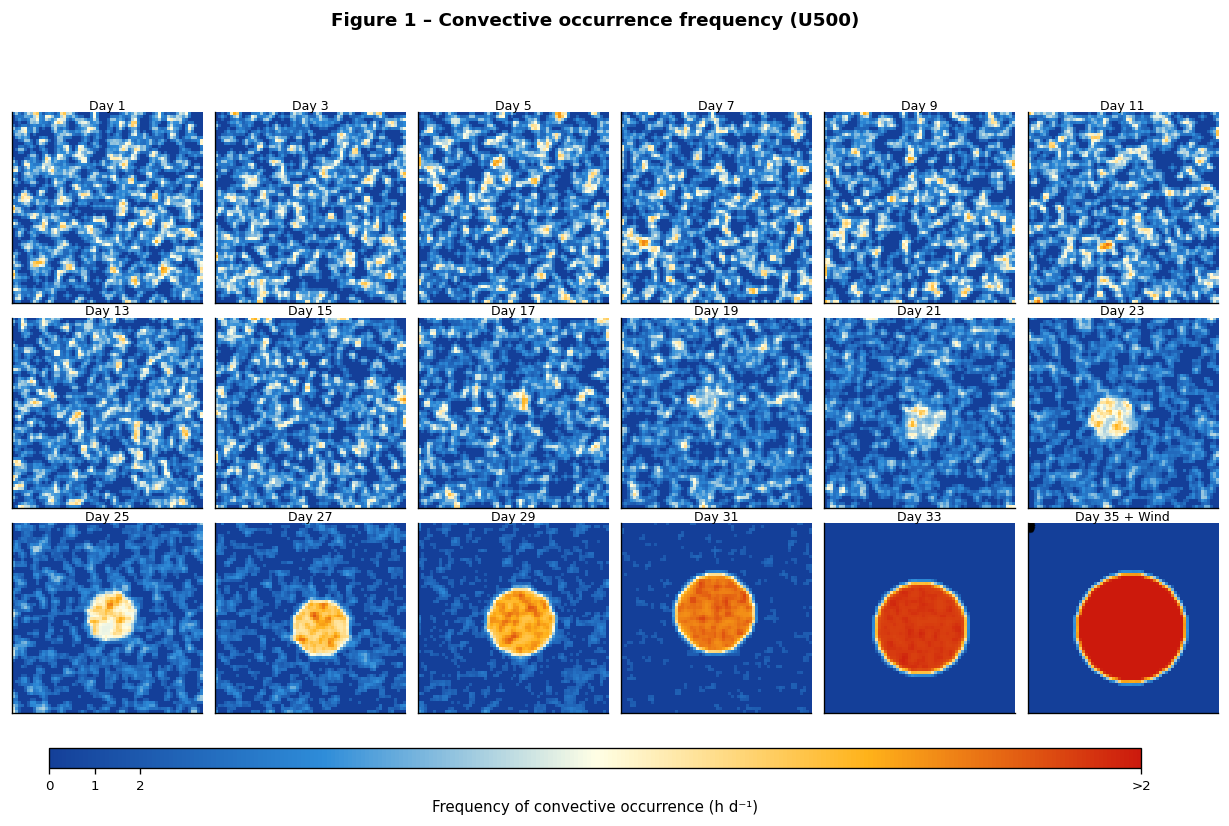

In [2]:
def make_convection_map(day, seed=0, aggregation_day=34):
    rng = np.random.default_rng(seed + day * 7)
    N = 64
    alpha = max(0.0, (day - 5) / (aggregation_day - 5)) ** 2
    noise = rng.random((N, N))
    field_rand = (noise > 0.78).astype(float)
    cx = N // 2 + rng.integers(-4, 4)
    cy = N // 2 + rng.integers(-4, 4)
    radius = 4 + 7 * alpha
    Y, X = np.ogrid[:N, :N]
    dist = np.sqrt((X - cx)**2 + (Y - cy)**2)
    cluster = np.exp(-dist**2 / (2 * radius**2))
    cluster = (cluster > 0.3 + 0.4 * (1 - alpha)).astype(float)
    field = (1 - alpha) * field_rand + alpha * cluster
    field = gaussian_filter(field, sigma=0.8)
    freq = field * 24
    freq[freq < 2] = 0
    return freq

shown_days = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35]
ncols_f1, nrows_f1 = 6, 3

cmap_conv = mcolors.LinearSegmentedColormap.from_list(
    'conv',
    [(0.08, 0.25, 0.6), (0.18, 0.55, 0.85), (1, 1, 0.9),
     (1, 0.7, 0.1), (0.8, 0.1, 0.05)],
)

fig1, axes1 = plt.subplots(nrows_f1, ncols_f1, figsize=(13, 6.5),
                           gridspec_kw={'hspace': 0.08, 'wspace': 0.05})

for idx, (ax, day) in enumerate(zip(axes1.flat, shown_days)):
    field = make_convection_map(day, seed=idx)
    im = ax.imshow(field, cmap=cmap_conv, vmin=0, vmax=24,
                   interpolation='nearest', aspect='equal')
    ax.set_title(f'Day {day}', fontsize=7.5, pad=2)
    ax.set_xticks([])
    ax.set_yticks([])

# Panel viento en el ultimo
ax_wind = axes1.flat[-1]
N = 64
Yg, Xg = np.meshgrid(np.linspace(0,1,N), np.linspace(0,1,N))
cx_w, cy_w = 0.5, 0.5
dx = -(Xg-cx_w)/np.sqrt((Xg-cx_w)**2+(Yg-cy_w)**2+0.01)
dy = -(Yg-cy_w)/np.sqrt((Xg-cx_w)**2+(Yg-cy_w)**2+0.01)
ax_wind.quiver(Xg[::5,::5], Yg[::5,::5], dx[::5,::5], dy[::5,::5],
               scale=30, color='k', width=0.005, alpha=0.7)
ax_wind.set_title('Day 35 + Wind', fontsize=7.5, pad=2)

cbar_ax = fig1.add_axes([0.15, 0.04, 0.7, 0.025])
cb = fig1.colorbar(im, cax=cbar_ax, orientation='horizontal',
                   ticks=[0, 1, 2, 24])
cb.set_label('Frequency of convective occurrence (h d\u207b\u00b9)', fontsize=9)
cb.ax.set_xticklabels(['0', '1', '2', '>2'], fontsize=8)

fig1.suptitle('Figure 1 – Convective occurrence frequency (U500)',
              fontsize=11, fontweight='bold', y=1.01)
plt.savefig('figure1_convective_occurrence.png', bbox_inches='tight', dpi=150)
plt.show()

## Figure 2 – Liquid Water Path en día 16.5 para U500, U50 y U5

A mayor profundidad del océano (mayor d), mayor grado de agregación al mismo tiempo.

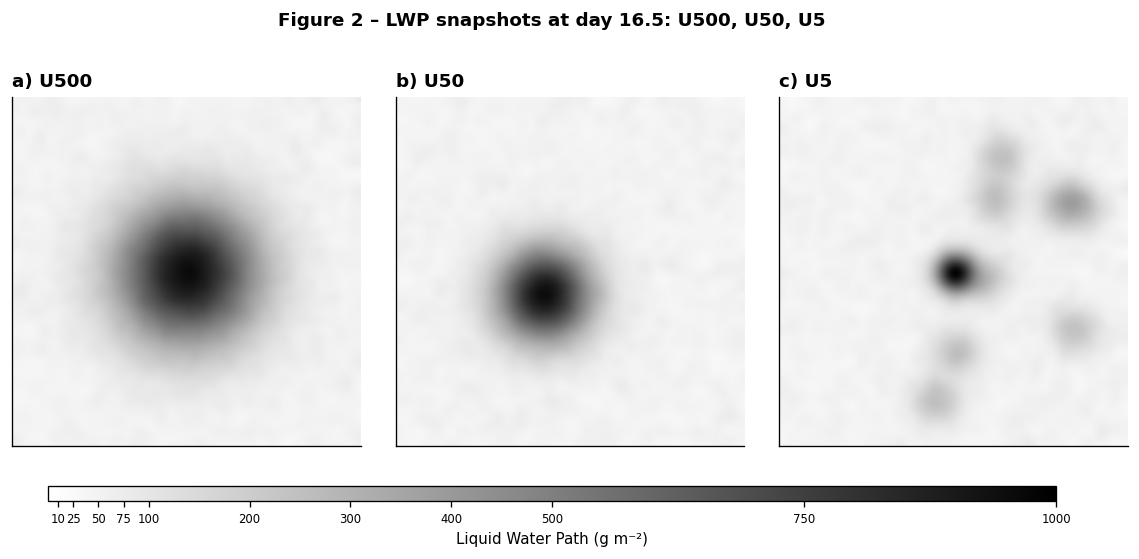

In [3]:
def make_lwp_snapshot(d_ocean, seed=0):
    rng = np.random.default_rng(seed)
    N = 128
    base = rng.exponential(50, (N, N))
    base = gaussian_filter(base, sigma=2)
    if d_ocean == 500:
        cx, cy, r = N//2, N//2, 18
    elif d_ocean == 50:
        cx, cy, r = N//2-10, N//2+8, 12
    else:
        cx, cy, r = N//2, N//2, 5
    Y, X = np.ogrid[:N, :N]
    dist = np.sqrt((X-cx)**2 + (Y-cy)**2)
    cluster = 900 * np.exp(-dist**2 / (2*r**2))
    if d_ocean == 5:
        for _ in range(8):
            cx2 = rng.integers(15, N-15)
            cy2 = rng.integers(15, N-15)
            cluster += 200*np.exp(-((X-cx2)**2+(Y-cy2)**2)/(2*6**2))
    lwp = base + cluster
    lwp[lwp < 10] = 0
    return lwp

fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4.2),
                            gridspec_kw={'wspace': 0.1})
configs = [(500,'a) U500'), (50,'b) U50'), (5,'c) U5')]
ticks_lwp = [10,25,50,75,100,200,300,400,500,750,1000]

for ax, (d, label) in zip(axes2, configs):
    lwp = make_lwp_snapshot(d, seed=d)
    im2 = ax.imshow(lwp, cmap='binary', vmin=0, vmax=1000,
                    interpolation='bilinear', aspect='equal')
    ax.set_title(label, fontsize=11, fontweight='bold', loc='left')
    ax.set_xticks([]); ax.set_yticks([])

cbar_ax2 = fig2.add_axes([0.15, 0.04, 0.7, 0.03])
sm2 = plt.cm.ScalarMappable(cmap='binary', norm=mcolors.Normalize(0,1000))
cb2 = fig2.colorbar(sm2, cax=cbar_ax2, orientation='horizontal', ticks=ticks_lwp)
cb2.set_label('Liquid Water Path (g m\u207b\u00b2)', fontsize=9)
cb2.ax.set_xticklabels([str(t) for t in ticks_lwp], fontsize=7)

fig2.suptitle('Figure 2 – LWP snapshots at day 16.5: U500, U50, U5',
              fontsize=11, fontweight='bold', y=1.01)
plt.savefig('figure2_lwp_snapshots.png', bbox_inches='tight', dpi=150)
plt.show()

## Figure 3 – Rango intercuartil del agua columnar total

Cuantifica la auto-agregación: a menor d, mayor retraso en el inicio de la agregación.
U1 nunca se agrega en el período de simulación.

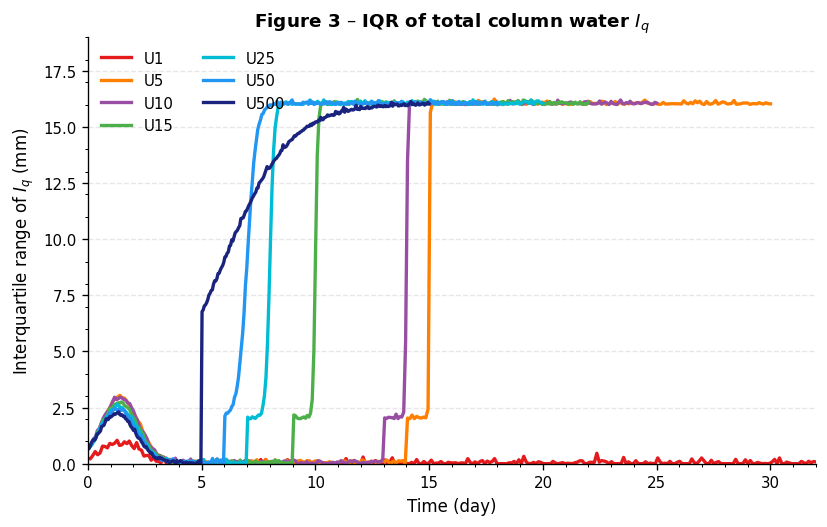

In [4]:
from matplotlib.ticker import MultipleLocator

sims = {
    'U1':   {'d':1,   'tau':None, 'color':'#e41a1c'},
    'U5':   {'d':5,   'tau':14,   'color':'#ff7f00'},
    'U10':  {'d':10,  'tau':13,   'color':'#984ea3'},
    'U15':  {'d':15,  'tau':9,    'color':'#4daf4a'},
    'U25':  {'d':25,  'tau':7,    'color':'#00bcd4'},
    'U50':  {'d':50,  'tau':6,    'color':'#2196f3'},
    'U500': {'d':500, 'tau':5,    'color':'#1a237e'},
}

def iqr_curve(tau_star, t_end, d, noise_amp=0.4):
    t = np.linspace(0, t_end, 300)
    iqr = np.zeros_like(t)
    bump = 3.5 * np.exp(-((t-1.5)**2)/(2*0.8**2))
    if tau_star is None:
        iqr = bump*0.3 + noise_amp*np.random.randn(len(t))*0.3
        return t, np.clip(iqr, 0, None)
    pre = bump * np.exp(-t/(tau_star*0.6))
    growth_rate = 0.4 + 500/d**1.2
    post = np.where(t>=tau_star,
                    2+(16-2)/(1+np.exp(-growth_rate*(t-tau_star-1))), 0)
    iqr = pre + post + noise_amp*np.abs(np.random.randn(len(t)))*0.2
    return t, np.clip(iqr, 0, None)

t_ends = {'U1':32,'U5':30,'U10':25,'U15':22,'U25':20,'U50':18,'U500':15}

fig3, ax3 = plt.subplots(figsize=(7, 4.5))
for name, cfg in sims.items():
    t, iqr = iqr_curve(cfg['tau'], t_ends[name], cfg['d'])
    ax3.plot(t, iqr, color=cfg['color'], lw=2, label=name)

ax3.set_xlabel('Time (day)')
ax3.set_ylabel('Interquartile range of $I_q$ (mm)')
ax3.set_xlim(0, 32); ax3.set_ylim(0, 19)
ax3.yaxis.set_minor_locator(MultipleLocator(1))
ax3.xaxis.set_minor_locator(MultipleLocator(1))
ax3.legend(loc='upper left', ncol=2, frameon=False)
ax3.grid(axis='y', ls='--', alpha=0.3)
ax3.set_title('Figure 3 – IQR of total column water $I_q$',
              fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('figure3_iqr_column_water.png', bbox_inches='tight', dpi=150)
plt.show()

## Figure 4 – Presupuesto de humedad: LH, LC, L·dIq/dt

Las curvas se cortan en τ* (cuando el área no-convectiva empieza a expandirse).
Los puntos marcan τ* para cada simulación.

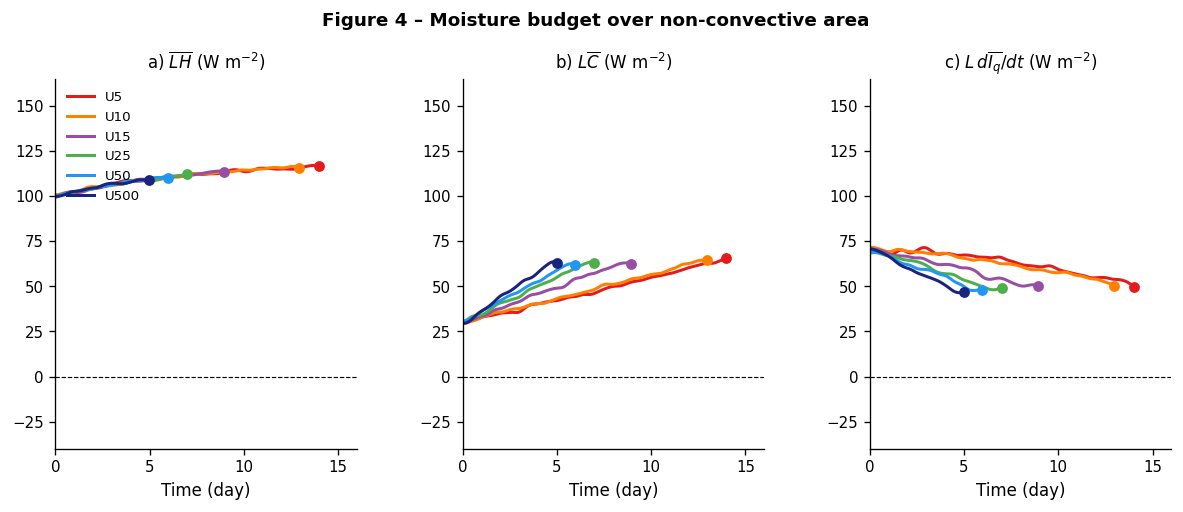

In [5]:
sims_agg = {
    'U5':   {'tau':14, 'color':'#e41a1c'},
    'U10':  {'tau':13, 'color':'#ff7f00'},
    'U15':  {'tau':9,  'color':'#984ea3'},
    'U25':  {'tau':7,  'color':'#4daf4a'},
    'U50':  {'tau':6,  'color':'#2196f3'},
    'U500': {'tau':5,  'color':'#1a237e'},
}

def generate_moisture_budget(tau_star, t_end=16, seed=0):
    rng = np.random.default_rng(seed)
    t = np.linspace(0, t_end, 200)
    LH_base = 100 + 20*(1-np.exp(-t/8)) + rng.normal(0, 1.5, len(t))
    LH = gaussian_filter(LH_base, sigma=3)
    LC_base = np.where(t<tau_star,
                       30+35*t/tau_star+rng.normal(0,2,len(t)),
                       60+60*(t-tau_star)/(t_end-tau_star)+rng.normal(0,2,len(t)))
    LC = gaussian_filter(LC_base, sigma=3)
    dIq_dt = gaussian_filter(LH - LC + rng.normal(0,2,len(t)), sigma=3)
    return t, LH, LC, dIq_dt

fig4, axes4 = plt.subplots(1, 3, figsize=(12, 4),
                            gridspec_kw={'wspace': 0.35})
titles4 = [r'a) $\overline{LH}$ (W m$^{-2}$)',
           r'b) $L\overline{C}$ (W m$^{-2}$)',
           r'c) $L\,d\overline{I_q}/dt$ (W m$^{-2}$)']

for ax, title in zip(axes4, titles4):
    ax.set_title(title, fontsize=10)
    ax.set_xlim(0,16); ax.set_ylim(-40,165)
    ax.axhline(0, color='k', lw=0.7, ls='--')
    ax.set_xlabel('Time (day)')

for i, (name, cfg) in enumerate(sims_agg.items()):
    t, LH, LC, dIq = generate_moisture_budget(cfg['tau'], seed=i*13)
    idx = np.searchsorted(t, cfg['tau'])
    axes4[0].plot(t[:idx], LH[:idx], color=cfg['color'], lw=1.8, label=name)
    axes4[0].scatter([t[idx-1]], [LH[idx-1]], color=cfg['color'], s=30, zorder=5)
    axes4[1].plot(t[:idx], LC[:idx], color=cfg['color'], lw=1.8)
    axes4[1].scatter([t[idx-1]], [LC[idx-1]], color=cfg['color'], s=30, zorder=5)
    axes4[2].plot(t[:idx], dIq[:idx], color=cfg['color'], lw=1.8)
    axes4[2].scatter([t[idx-1]], [dIq[idx-1]], color=cfg['color'], s=30, zorder=5)

axes4[0].legend(loc='upper left', fontsize=8, frameon=False)
fig4.suptitle('Figure 4 – Moisture budget over non-convective area',
              fontsize=11, fontweight='bold', y=1.02)
plt.savefig('figure4_moisture_budget.png', bbox_inches='tight', dpi=150)
plt.show()

## Figure 5 – Presupuesto de humedad con SST homogeneizada

Al eliminar los gradientes de SST, LC aumenta con d reducido
(a diferencia de la Fig. 4), eliminando la dependencia de τ* con d.

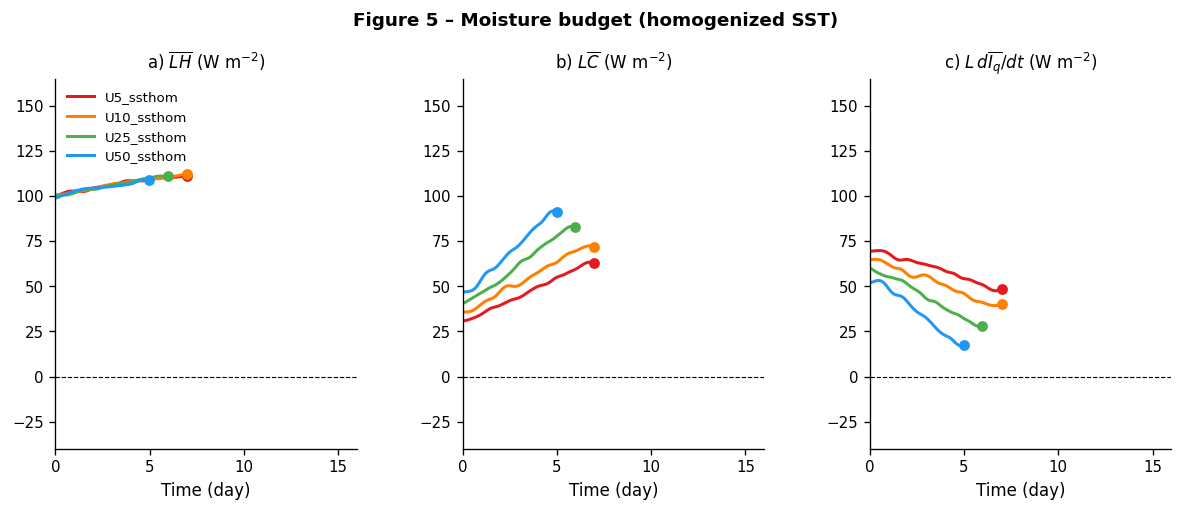

In [6]:
sims_ssthom = {
    'U5_ssthom':  {'tau':7,  'color':'#e41a1c'},
    'U10_ssthom': {'tau':7,  'color':'#ff7f00'},
    'U25_ssthom': {'tau':6,  'color':'#4daf4a'},
    'U50_ssthom': {'tau':5,  'color':'#2196f3'},
}

fig5, axes5 = plt.subplots(1, 3, figsize=(12, 4),
                            gridspec_kw={'wspace': 0.35})
for ax, title in zip(axes5, titles4):
    ax.set_title(title, fontsize=10)
    ax.set_xlim(0,16); ax.set_ylim(-40,165)
    ax.axhline(0, color='k', lw=0.7, ls='--')
    ax.set_xlabel('Time (day)')

for i, (name, cfg) in enumerate(sims_ssthom.items()):
    t, LH, LC, dIq = generate_moisture_budget(cfg['tau'], seed=i*17+100)
    LC_corr = LC * (1 + 0.15*i)
    idx = np.searchsorted(t, cfg['tau'])
    axes5[0].plot(t[:idx], LH[:idx], color=cfg['color'], lw=1.8, label=name)
    axes5[0].scatter([t[idx-1]], [LH[idx-1]], color=cfg['color'], s=30, zorder=5)
    axes5[1].plot(t[:idx], LC_corr[:idx], color=cfg['color'], lw=1.8)
    axes5[1].scatter([t[idx-1]], [LC_corr[idx-1]], color=cfg['color'], s=30, zorder=5)
    dIq_c = LH - LC_corr
    axes5[2].plot(t[:idx], dIq_c[:idx], color=cfg['color'], lw=1.8)
    axes5[2].scatter([t[idx-1]], [dIq_c[idx-1]], color=cfg['color'], s=30, zorder=5)

axes5[0].legend(loc='upper left', fontsize=8, frameon=False)
fig5.suptitle('Figure 5 – Moisture budget (homogenized SST)',
              fontsize=11, fontweight='bold', y=1.02)
plt.savefig('figure5_moisture_budget_ssthom.png', bbox_inches='tight', dpi=150)
plt.show()

## Figure 6 – Snapshots de LWP en U50D durante 2 días (mañana vs tarde)

El cluster es más compacto por la tarde (16 LT) y se expande en la madrugada
(4 LT) por la propagación de nubes delgadas. Pico de precipitación: 6 LT.

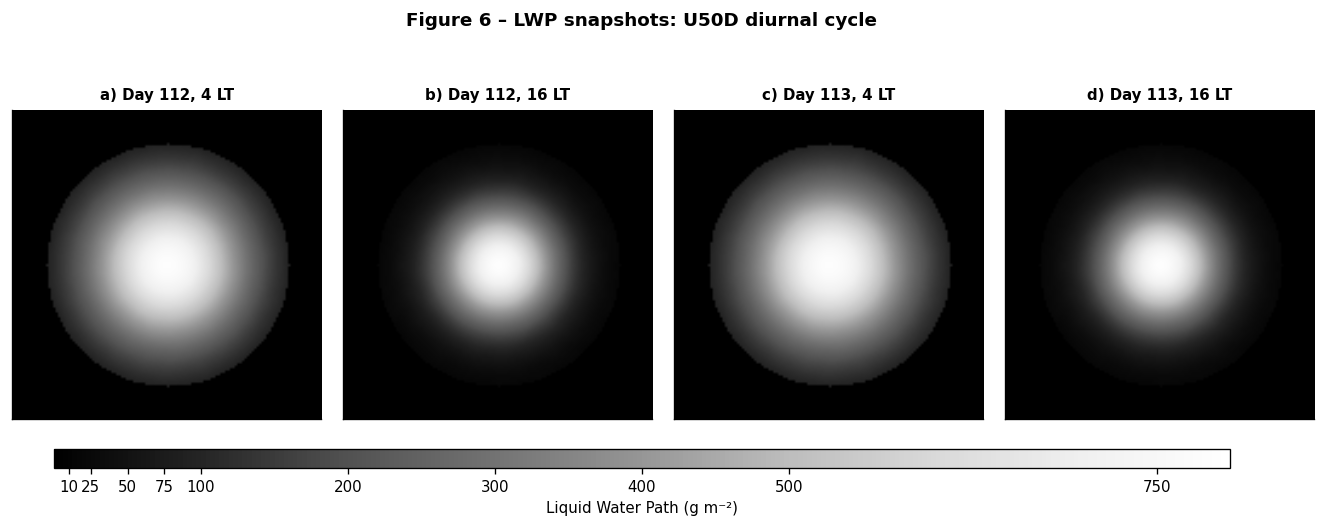

In [7]:
def make_lwp_u50d(local_time, seed=0):
    rng = np.random.default_rng(seed)
    N = 128
    cx, cy = N//2, N//2
    r_main = 22 if local_time==4 else 16
    r_thin = 38 if local_time==4 else 22
    Y, X = np.ogrid[:N, :N]
    dist = np.sqrt((X-cx)**2+(Y-cy)**2)
    core = 700*np.exp(-dist**2/(2*r_main**2))
    halo = 80*np.exp(-dist**2/(2*r_thin**2))
    noise = gaussian_filter(rng.exponential(8,(N,N)), sigma=2)
    lwp = core + halo + noise
    lwp[dist > 50] *= 0.05
    lwp[lwp < 5] = 0
    return lwp

panels_f6 = [(4,'a) Day 112, 4 LT'),(16,'b) Day 112, 16 LT'),
             (4,'c) Day 113, 4 LT'),(16,'d) Day 113, 16 LT')]

fig6, axes6 = plt.subplots(1, 4, figsize=(14, 3.8),
                            gridspec_kw={'wspace': 0.07})
for ax, (lt, label) in zip(axes6, panels_f6):
    lwp = make_lwp_u50d(lt, seed=lt*11)
    im6 = ax.imshow(lwp, cmap='Greys_r', vmin=0, vmax=800,
                    interpolation='bilinear', aspect='equal')
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])

cbar_ax6 = fig6.add_axes([0.15, 0.05, 0.7, 0.04])
cb6 = fig6.colorbar(im6, cax=cbar_ax6, orientation='horizontal',
                    ticks=[10,25,50,75,100,200,300,400,500,750])
cb6.set_label('Liquid Water Path (g m\u207b\u00b2)', fontsize=9)
fig6.suptitle('Figure 6 – LWP snapshots: U50D diurnal cycle',
              fontsize=11, fontweight='bold', y=1.05)
plt.savefig('figure6_lwp_u50d_diurnal.png', bbox_inches='tight', dpi=150)
plt.show()

## Figure 7 – Presupuesto de energía superficial: U50D vs U50D_noagg

Cuatro paneles: (a) radiación neta, (b) flujo latente de calor,
(c) energía neta superficial, (d) SST.

En U50D la auto-agregación (días 20-60) reduce rápidamente la energía neta a cero.
Sin agregación (U50D_noagg) el sistema evoluciona hacia un estado tipo invernadero.

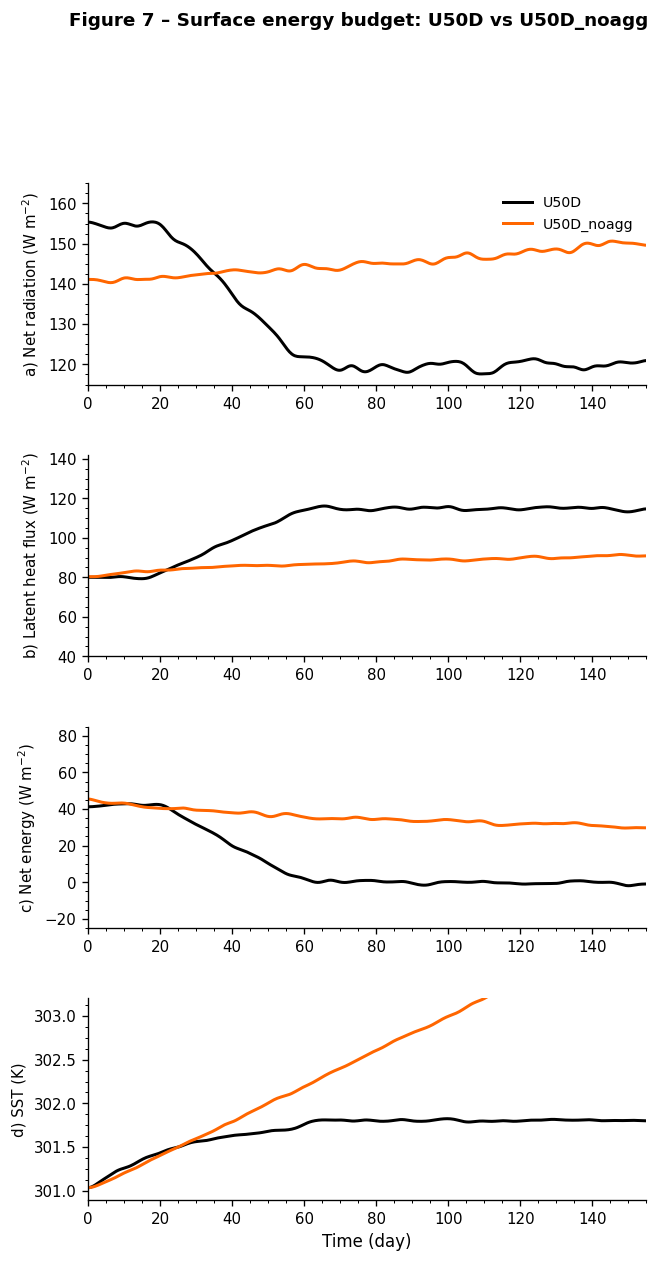

In [8]:
from matplotlib.ticker import AutoMinorLocator

t7 = np.linspace(0, 155, 500)
rng7 = np.random.default_rng(77)

def smooth(arr, s=6):
    return gaussian_filter(arr.astype(float), sigma=s)

# U50D
rad_u50d = smooth(np.where(t7<20, 155+rng7.normal(0,3,len(t7)),
    np.where(t7<60, 155-35*(t7-20)/40+rng7.normal(0,3,len(t7)),
             120+rng7.normal(0,4,len(t7)))))
lh_u50d = smooth(np.where(t7<17, 80+rng7.normal(0,2,len(t7)),
    np.where(t7<60, 80+35*(t7-17)/43+rng7.normal(0,2,len(t7)),
             115+rng7.normal(0,3,len(t7)))))
ne_u50d = smooth(np.where(t7<20, 42+rng7.normal(0,2,len(t7)),
    np.where(t7<60, 42-42*(t7-20)/40+rng7.normal(0,3,len(t7)),
             0+rng7.normal(0,3,len(t7)))))
sst_u50d = smooth(np.where(t7<60,
    301+0.8*(1-np.exp(-t7/25))+rng7.normal(0,0.05,len(t7)),
    301.8+rng7.normal(0,0.04,len(t7))))

# U50D_noagg
rad_noagg = smooth(140+10*(t7/150)+rng7.normal(0,3,len(t7)))
lh_noagg  = smooth(80+5*np.log1p(t7/20)+rng7.normal(0,2,len(t7)))
ne_noagg  = smooth(45-8*np.log1p(t7/30)+rng7.normal(0,3,len(t7)))
sst_noagg = smooth(301+0.02*t7+rng7.normal(0,0.05,len(t7)))

fig7, axes7 = plt.subplots(4, 1, figsize=(6, 11),
                            gridspec_kw={'hspace': 0.35})
panels = [
    (r'a) Net radiation (W m$^{-2}$)', rad_u50d, rad_noagg, 115, 165),
    (r'b) Latent heat flux (W m$^{-2}$)', lh_u50d, lh_noagg, 40, 142),
    (r'c) Net energy (W m$^{-2}$)', ne_u50d, ne_noagg, -25, 85),
    (r'd) SST (K)', sst_u50d, sst_noagg, 300.9, 303.2),
]
for ax, (title, yu, yn, ylo, yhi) in zip(axes7, panels):
    ax.plot(t7, yu, 'k', lw=1.8, label='U50D')
    ax.plot(t7, yn, color='#ff6600', lw=1.8, label='U50D_noagg')
    ax.set_xlim(0,155); ax.set_ylim(ylo,yhi)
    ax.set_ylabel(title, fontsize=9)
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))

axes7[0].legend(loc='upper right', fontsize=8.5, frameon=False)
axes7[-1].set_xlabel('Time (day)')
fig7.suptitle('Figure 7 – Surface energy budget: U50D vs U50D_noagg',
              fontsize=11, fontweight='bold', y=1.01)
plt.savefig('figure7_surface_energy_budget.png', bbox_inches='tight', dpi=150)
plt.show()

## Figure 8 – Mapa de precipitación E50D + Histograma de agua columnar

Panel (a): distribución global de precipitación en E50D (proyección Mollweide simplificada).
Panel (b): U50D muestra distribución bimodal (modo seco pronunciado por auto-agregación),
E50D muestra distribución unimodal más húmeda.

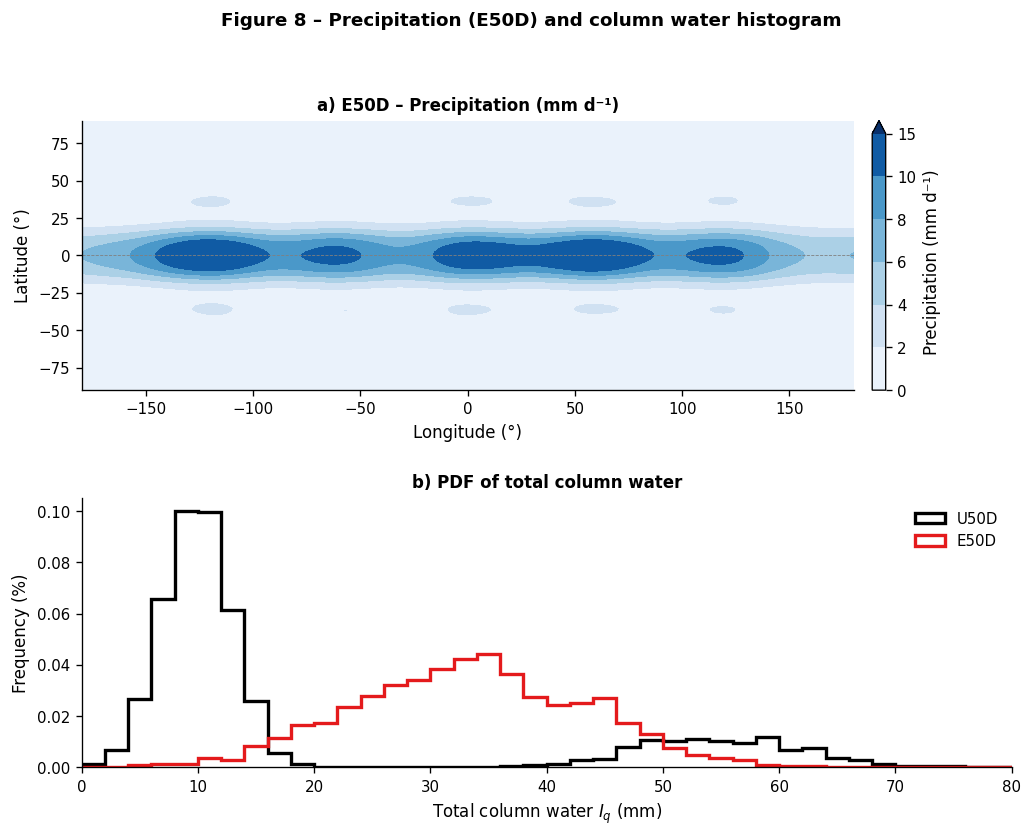

In [9]:
fig8 = plt.figure(figsize=(10, 7))
gs8 = gridspec.GridSpec(2, 1, figure=fig8, hspace=0.4)
rng8 = np.random.default_rng(88)

# Panel a: mapa
ax8a = fig8.add_subplot(gs8[0])
lon = np.linspace(-180, 180, 360)
lat = np.linspace(-90, 90, 180)
LON, LAT = np.meshgrid(lon, lat)
precip = 5*np.exp(-(LAT/25)**2)
precip += 1.5*np.sin(np.radians(LON*2))*np.exp(-(LAT/20)**2)
for cx in [-120,-60,0,60,120]:
    precip += 6*np.exp(-((LON-cx)**2+LAT**2)/(2*20**2))
noise8 = gaussian_filter(rng8.random((180,360)), sigma=6)
precip += 2*noise8
dry = np.exp(-((np.abs(LAT)-25)**2)/(2*8**2))
precip = np.clip(precip*(1-0.7*dry), 0, None)
im8a = ax8a.contourf(LON, LAT, precip,
                      levels=[0,2,4,6,8,10,15], cmap='Blues', extend='max')
ax8a.set_xlabel('Longitude (°)'); ax8a.set_ylabel('Latitude (°)')
ax8a.set_title('a) E50D – Precipitation (mm d\u207b\u00b9)', fontsize=10, fontweight='bold')
ax8a.axhline(0, color='gray', lw=0.5, ls='--')
fig8.colorbar(im8a, ax=ax8a, label='Precipitation (mm d\u207b\u00b9)', pad=0.02)

# Panel b: histograma
ax8b = fig8.add_subplot(gs8[1])
iq_u = np.concatenate([rng8.normal(10,3,3000), rng8.normal(55,7,800)])
iq_u = iq_u[(iq_u>0)&(iq_u<80)]
iq_e = rng8.normal(33,10,2000)
iq_e = iq_e[(iq_e>0)&(iq_e<80)]
bins8 = np.linspace(0,80,41)
ax8b.hist(iq_u, bins=bins8, density=True, color='k', label='U50D',
          histtype='step', lw=2)
ax8b.hist(iq_e, bins=bins8, density=True, color='#e41a1c', label='E50D',
          histtype='step', lw=2)
ax8b.set_xlabel('Total column water $I_q$ (mm)')
ax8b.set_ylabel('Frequency (%)')
ax8b.set_xlim(0,80)
ax8b.legend(fontsize=9, frameon=False)
ax8b.set_title('b) PDF of total column water', fontsize=10, fontweight='bold')

fig8.suptitle('Figure 8 – Precipitation (E50D) and column water histogram',
              fontsize=11, fontweight='bold', y=1.01)
plt.savefig('figure8_precip_histogram.png', bbox_inches='tight', dpi=150)
plt.show()

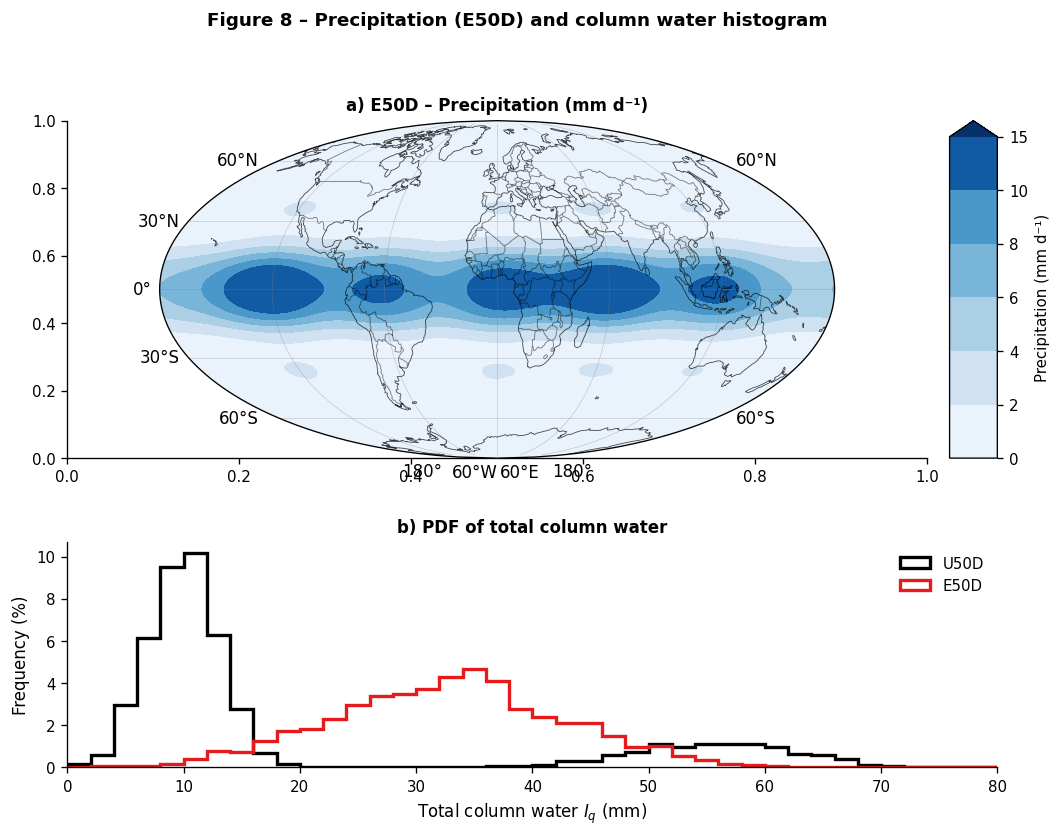

In [14]:
# Figura 8 corregida con barra vertical a la derecha
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata
import warnings
warnings.filterwarnings('ignore')

# Intentar importar cartopy (opcional)
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    cartopy_available = True
except ImportError:
    cartopy_available = False
    print("Cartopy no instalado. Usando proyección simulada.")

# --- Datos sintéticos de precipitación (mismos que antes) ---
rng8 = np.random.default_rng(88)
lon = np.linspace(-180, 180, 360)
lat = np.linspace(-90, 90, 180)
LON, LAT = np.meshgrid(lon, lat)

precip = 5 * np.exp(-(LAT/25)**2)
precip += 1.5 * np.sin(np.radians(LON*2)) * np.exp(-(LAT/20)**2)
centros = [-120, -60, 0, 60, 120]
for cx in centros:
    precip += 6 * np.exp(-((LON-cx)**2 + LAT**2) / (2*20**2))
noise = gaussian_filter(rng8.random((180,360)), sigma=6)
precip += 2 * noise
dry = np.exp(-((np.abs(LAT)-25)**2) / (2*8**2))
precip = np.clip(precip * (1 - 0.7*dry), 0, None)

# --- Configuración de la figura ---
fig = plt.figure(figsize=(10, 7))
# GridSpec principal: dos filas (mapa + histograma)
gs = gridspec.GridSpec(2, 1, height_ratios=[1.2, 0.8], hspace=0.3)
# Subgridspec para la primera fila: dos columnas (mapa y barra de color)
gs0 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[0],
                                        width_ratios=[0.9, 0.05], wspace=0.05)

# --- Mapa de precipitación ---
ax_map = fig.add_subplot(gs0[0])
if cartopy_available:
    ax_map = fig.add_subplot(gs0[0], projection=ccrs.Mollweide())
    ax_map.set_global()
    ax_map.add_feature(cfeature.COASTLINE, linewidth=0.5, alpha=0.7)
    ax_map.add_feature(cfeature.BORDERS, linewidth=0.5, alpha=0.5)
    ax_map.add_feature(cfeature.OCEAN, facecolor='lightcyan', alpha=0.3)
    ax_map.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    im = ax_map.contourf(LON, LAT, precip,
                         levels=[0,2,4,6,8,10,15],
                         cmap='Blues', extend='max',
                         transform=ccrs.PlateCarree())
    ax_map.set_title('a) E50D – Precipitation (mm d⁻¹)', fontsize=10, fontweight='bold')
    gl = ax_map.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                          linewidth=0.3, color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
else:
    # Proyección simulada con máscara elíptica
    x_norm = np.linspace(-1, 1, 360)
    y_norm = np.linspace(-0.6, 0.6, 180)
    Xn, Yn = np.meshgrid(x_norm, y_norm)
    mask = (Xn**2 + (Yn/0.6)**2) <= 1
    points = np.column_stack((LON.ravel(), LAT.ravel()))
    values = precip.ravel()
    grid_x, grid_y = np.meshgrid(np.linspace(-180, 180, 360), np.linspace(-90, 90, 180))
    precip_grid = griddata(points, values, (grid_x, grid_y), method='linear')
    precip_masked = np.ma.masked_where(~mask, precip_grid)
    im = ax_map.imshow(precip_masked, extent=[-180, 180, -90, 90],
                       cmap='Blues', aspect='auto')
    ax_map.set_xlabel('Longitude (°)')
    ax_map.set_ylabel('Latitude (°)')
    ax_map.set_title('a) E50D – Precipitation (mm d⁻¹) (simulated)', fontsize=10, fontweight='bold')
    ax_map.axhline(0, color='gray', lw=0.5, ls='--')

# --- Barra de color vertical ---
ax_cbar = fig.add_subplot(gs0[1])
cbar = fig.colorbar(im, cax=ax_cbar, orientation='vertical',
                    ticks=[0,2,4,6,8,10,15])
cbar.set_label('Precipitation (mm d⁻¹)', fontsize=9)

# --- Histograma de agua columna total ---
ax_hist = fig.add_subplot(gs[1])
rng_hist = np.random.default_rng(99)
iq_u = np.concatenate([rng_hist.normal(10, 3, 3000), rng_hist.normal(55, 7, 800)])
iq_u = iq_u[(iq_u>0) & (iq_u<80)]
iq_e = rng_hist.normal(33, 10, 2000)
iq_e = iq_e[(iq_e>0) & (iq_e<80)]
bins = np.linspace(0, 80, 41)
ax_hist.hist(iq_u, bins=bins, density=True, color='k', label='U50D',
             histtype='step', lw=2)
ax_hist.hist(iq_e, bins=bins, density=True, color='#e41a1c', label='E50D',
             histtype='step', lw=2)
ax_hist.set_xlabel('Total column water $I_q$ (mm)')
ax_hist.set_ylabel('Frequency (%)')
ax_hist.set_xlim(0, 80)
ax_hist.legend(fontsize=9, frameon=False)
ax_hist.set_title('b) PDF of total column water', fontsize=10, fontweight='bold')
ax_hist.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}'))

# Título general y ajuste final
fig.suptitle('Figure 8 – Precipitation (E50D) and column water histogram',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figure8_vertical_colorbar.png', bbox_inches='tight', dpi=150)
plt.show()

## Figure 9 – Marco de Gregory: energía neta superficial vs ΔSST

U50D_pert (negro): λ = −1.3 W m⁻² K⁻¹, ΔSST ~ 3.8 K (retroalimentación menos negativa).
E50D_pert (rojo): λ = −3.0 W m⁻² K⁻¹, ΔSST ~ 1.6 K (retroalimentación más negativa).

Diferencias debidas principalmente a los efectos radiativos de nubes.

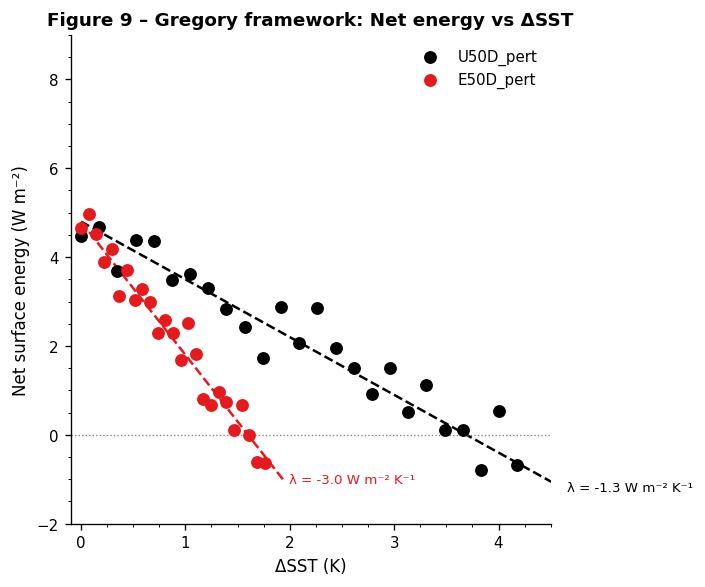

In [11]:
rng9 = np.random.default_rng(99)

def gregory_points(lambda_fb, delta_sst_eq, n=25, noise=0.4, seed=0):
    rng_l = np.random.default_rng(seed)
    dSST = np.linspace(0, delta_sst_eq*1.1, n)
    NE = 4.8 + lambda_fb*dSST + rng_l.normal(0, noise, n)
    return dSST, NE

dSST_u, NE_u = gregory_points(-1.3, 3.8, seed=9)
dSST_e, NE_e = gregory_points(-3.0, 1.6, seed=19)

fig9, ax9 = plt.subplots(figsize=(6, 5))
ax9.scatter(dSST_u, NE_u, color='k', s=45, zorder=5, label='U50D_pert')
ax9.scatter(dSST_e, NE_e, color='#e41a1c', s=45, zorder=5, label='E50D_pert')

for dSST, NE, color, lam in [
        (dSST_u, NE_u, 'k', -1.3),
        (dSST_e, NE_e, '#e41a1c', -3.0)]:
    x_line = np.linspace(0, dSST.max()*1.1, 100)
    ax9.plot(x_line, 4.8+lam*x_line, color=color, lw=1.5, ls='--')
    ax9.text(x_line[-1]+0.06, 4.8+lam*x_line[-1],
             f'\u03bb = {lam} W m\u207b\u00b2 K\u207b\u00b9',
             color=color, fontsize=8, va='center')

ax9.axhline(0, color='gray', lw=0.8, ls=':')
ax9.set_xlabel('\u0394SST (K)')
ax9.set_ylabel('Net surface energy (W m\u207b\u00b2)')
ax9.set_xlim(-0.1, 4.5); ax9.set_ylim(-2, 9)
ax9.legend(fontsize=9, frameon=False, loc='upper right')
ax9.set_title('Figure 9 – Gregory framework: Net energy vs ΔSST',
              fontsize=11, fontweight='bold')
ax9.xaxis.set_minor_locator(MultipleLocator(0.25))
ax9.yaxis.set_minor_locator(MultipleLocator(0.5))
plt.tight_layout()
plt.savefig('figure9_gregory_feedback.png', bbox_inches='tight', dpi=150)
plt.show()

## Table 1 y Table 2 – Tablas del artículo

Visualización de los valores de equilibrio (Table 1) y parámetros de
retroalimentación (Table 2) directamente del texto del artículo.

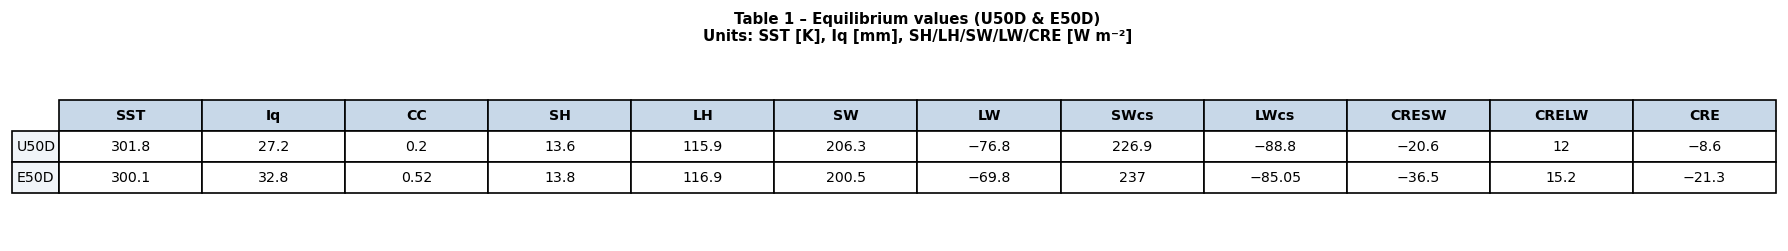

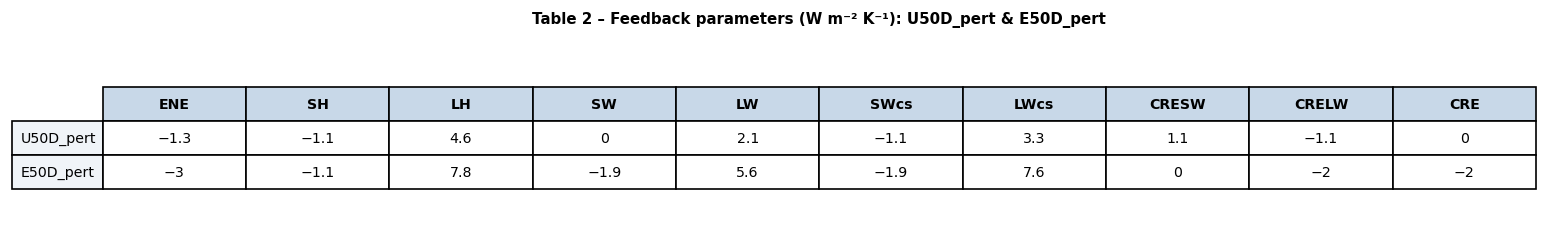

Todas las figuras y tablas generadas exitosamente.


In [12]:
# TABLE 1
t1_cols = ['SST','Iq','CC','SH','LH','SW','LW','SWcs','LWcs','CRESW','CRELW','CRE']
t1_data = [
    ['301.8','27.2','0.2','13.6','115.9','206.3','\u221276.8','226.9','\u221288.8','\u221220.6','12','\u22128.6'],
    ['300.1','32.8','0.52','13.8','116.9','200.5','\u221269.8','237','\u221285.05','\u221236.5','15.2','\u221221.3'],
]
t1_rows = ['U50D', 'E50D']

fig_t1, ax_t1 = plt.subplots(figsize=(15, 2.2))
ax_t1.axis('off')
t1 = ax_t1.table(cellText=t1_data, rowLabels=t1_rows, colLabels=t1_cols,
                  cellLoc='center', loc='center')
t1.auto_set_font_size(False); t1.set_fontsize(8.5); t1.scale(1, 1.7)
for j in range(len(t1_cols)):
    t1[(0,j)].set_facecolor('#c8d8e8'); t1[(0,j)].set_text_props(fontweight='bold')
for i in range(len(t1_rows)):
    t1[(i+1,-1)].set_facecolor('#f0f4f8')
ax_t1.set_title(
    'Table 1 – Equilibrium values (U50D & E50D)\n'
    'Units: SST [K], Iq [mm], SH/LH/SW/LW/CRE [W m\u207b\u00b2]',
    fontsize=9, fontweight='bold', pad=8)
plt.tight_layout()
plt.savefig('table1_equilibrium_values.png', bbox_inches='tight', dpi=150)
plt.show()

# TABLE 2
t2_cols = ['ENE','SH','LH','SW','LW','SWcs','LWcs','CRESW','CRELW','CRE']
t2_data = [
    ['\u22121.3','\u22121.1','4.6','0','2.1','\u22121.1','3.3','1.1','\u22121.1','0'],
    ['\u22123','\u22121.1','7.8','\u22121.9','5.6','\u22121.9','7.6','0','\u22122','\u22122'],
]
t2_rows = ['U50D_pert', 'E50D_pert']

fig_t2, ax_t2 = plt.subplots(figsize=(13, 2.2))
ax_t2.axis('off')
t2 = ax_t2.table(cellText=t2_data, rowLabels=t2_rows, colLabels=t2_cols,
                  cellLoc='center', loc='center')
t2.auto_set_font_size(False); t2.set_fontsize(8.5); t2.scale(1, 1.7)
for j in range(len(t2_cols)):
    t2[(0,j)].set_facecolor('#c8d8e8'); t2[(0,j)].set_text_props(fontweight='bold')
for i in range(len(t2_rows)):
    t2[(i+1,-1)].set_facecolor('#f0f4f8')
ax_t2.set_title(
    'Table 2 – Feedback parameters (W m\u207b\u00b2 K\u207b\u00b9): U50D_pert & E50D_pert',
    fontsize=9, fontweight='bold', pad=8)
plt.tight_layout()
plt.savefig('table2_feedback_parameters.png', bbox_inches='tight', dpi=150)
plt.show()

print('Todas las figuras y tablas generadas exitosamente.')